Lekcja 18: Wprowadzenie do ML i typy uczenia

Scikit-learn (sklearn) to biblioteka Python dostarczająca proste i wydajne narzędzia do
analizy danych i uczenia maszynowego. Oferuje spójny interfejs API dla różnych
algorytmów, narzędzia do preprocessingu, walidacji i ewaluacji modeli.

Dlaczego scikit-learn?Definition
Scikit-learn (sklearn) to biblioteka Python dostarczająca proste i wydajne narzędzia do
analizy danych i uczenia maszynowego. Oferuje spójny interfejs API dla różnych
algorytmów, narzędzia do preprocessingu, walidacji i ewaluacji modeli.
graph TD
A[Scikit-learn] --> B[Spójne API]
A --> C[Dokumentacja]
A --> D[Społeczność]
A --> E[Integracja]
B --> B1[fit/predict/transform]
B --> B2[Łatwa zamiana algorytmów]
C --> C1[Przykłady kodu]
C --> C2[User Guide]
D --> D1[Stack Overflow]
D --> D2[GitHub Issues]
E --> E1[NumPy/Pandas]
E --> E2[Matplotlib]
E --> E3[Jupyter]

Przykład 1: Instalacja i podstawowa struktura sklearn

In [1]:
# Sprawdzenie wersji scikit-learn
import sklearn
print(f"Wersja scikit-learn: {sklearn.__version__}")
# Główne moduły scikit-learn
from sklearn import datasets # Wbudowane datasety
from sklearn import preprocessing # Skalowanie, kodowanie
from sklearn import model_selection # Train/test split, CV
from sklearn import metrics # Metryki ewaluacji
from sklearn import linear_model # Modele liniowe
from sklearn import tree # Drzewa decyzyjne
from sklearn import ensemble # Random Forest, Gradient Boosting
from sklearn import neighbors # k-NN
from sklearn import svm # Support Vector Machines
from sklearn import cluster # Klasteryzacja
# Przykład: wczytanie wbudowanego datasetu
iris = datasets.load_iris()
print(f"\nDataset Iris:")
print(f" Cechy: {iris.feature_names}")
print(f" Klasy: {iris.target_names}")
print(f" Rozmiar X: {iris.data.shape}")
print(f" Rozmiar y: {iris.target.shape}")
# Konwersja do DataFrame dla wygody
import pandas as pd
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2:
'virginica'})
print(f"\nPierwsze 5 wierszy:")
print(df.head())

Wersja scikit-learn: 1.6.1

Dataset Iris:
 Cechy: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
 Klasy: ['setosa' 'versicolor' 'virginica']
 Rozmiar X: (150, 4)
 Rozmiar y: (150,)

Pierwsze 5 wierszy:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  


Przykład 2: Uniwersalny interfejs API sklearn

In [8]:
# Scikit-learn ma spójny interfejs dla WSZYSTKICH algorytmów:
# 1. fit(X, y) - uczenie modelu na danych
# 2. predict(X) - predykcja dla nowych danych
# 3. score(X, y) - ewaluacja modelu
# 4. transform(X) - transformacja danych (dla preprocessorów)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Wczytanie danych
iris = load_iris()
X, y = iris.data, iris.target
# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.3, # 30% na test
random_state=42, # dla reprodukowalności
stratify=y # zachowanie proporcji klas
)
print(f"Rozmiar zbioru treningowego: {X_train.shape[0]}")
print(f"Rozmiar zbioru testowego: {X_test.shape[0]}")
# Porównanie różnych algorytmów - TEN SAM interfejs!
models = {
'Logistic Regression': LogisticRegression(max_iter=200),
'Decision Tree': DecisionTreeClassifier(random_state=42),
'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
'Random Forest': RandomForestClassifier(n_estimators=100,
random_state=42)
}
print("\nPorównanie algorytmów:")
print("-" * 50)
for name, model in models.items():
    # TEN SAM kod dla każdego modelu!
    model.fit(X_train, y_train) # Trening
    train_score = model.score(X_train, y_train) # Accuracy na train
    test_score = model.score(X_test, y_test) # Accuracy na test
    print(f"{name:25s} | Train: {train_score:.3f} | Test: {test_score:.3f}")

Rozmiar zbioru treningowego: 105
Rozmiar zbioru testowego: 45

Porównanie algorytmów:
--------------------------------------------------
Logistic Regression       | Train: 0.971 | Test: 0.933
Decision Tree             | Train: 1.000 | Test: 0.933
K-Nearest Neighbors       | Train: 0.971 | Test: 0.978
Random Forest             | Train: 1.000 | Test: 0.889


Przykład 3: Pełny workflow ML

In [6]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score, confusion_matrix,
classification_report)

# ========================================
# KROK 1: Wczytanie i eksploracja danych
# ========================================
data = load_breast_cancer()
X = data.data
y = data.target # 0 = malignant (złośliwy), 1 = benign (łagodny)
print("="*60)
print("BREAST CANCER DATASET - Pełny workflow ML")
print("="*60)
print(f"\nRozmiar: {X.shape[0]} próbek, {X.shape[1]} cech")
print(f"Klasy: {data.target_names}")
print(f"Rozkład klas: {np.bincount(y)}")
print(f" - Malignant: {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")
print(f" - Benign: {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")

# ========================================
# KROK 2: Podział na train/test
# ========================================
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42,
stratify=y # zachowaj proporcje klas
)
print(f"\nPodział danych:")
print(f" Train: {X_train.shape[0]} próbek")
print(f" Test: {X_test.shape[0]} próbek")

# ========================================
# KROK 3: Preprocessing - standaryzacja
# ========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # fit + transform na train
X_test_scaled = scaler.transform(X_test) # tylko transform na test!
print(f"\nPo standaryzacji:")
print(f" Mean (train): {X_train_scaled.mean():.6f}")
print(f" Std (train): {X_train_scaled.std():.6f}")

# ========================================
# KROK 4: Trening modelu
# ========================================
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
print(f"\nModel wytrenowany!")
print(f" Liczba iteracji: {model.n_iter_[0]}")

# ========================================
# KROK 5: Predykcja
# ========================================
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled) # prawdopodobieństwa
print(f"\nPrzykładowe predykcje (5 pierwszych):")
for i in range(5):
    print(f" Próbka {i}: pred={y_pred[i]}, "
f"proba=[{y_pred_proba[i][0]:.3f}, {y_pred_proba[i][1]:.3f}], "
f"true={y_test[i]}")

# ========================================
# KROK 6: Ewaluacja
# ========================================
print("\n" + "="*60)
print("EWALUACJA MODELU")
print("="*60)
# Metryki podstawowe
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nMetryki:")
print(f" Accuracy: {accuracy:.4f}")
print(f" Precision: {precision:.4f}")
print(f" Recall: {recall:.4f}")
print(f" F1-score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f" TN={cm[0,0]:3d} FP={cm[0,1]:3d}")
print(f" FN={cm[1,0]:3d} TP={cm[1,1]:3d}")

# Pełny raport
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

BREAST CANCER DATASET - Pełny workflow ML

Rozmiar: 569 próbek, 30 cech
Klasy: ['malignant' 'benign']
Rozkład klas: [212 357]
 - Malignant: 212 (37.3%)
 - Benign: 357 (62.7%)

Podział danych:
 Train: 455 próbek
 Test: 114 próbek

Po standaryzacji:
 Mean (train): -0.000000
 Std (train): 1.000000

Model wytrenowany!
 Liczba iteracji: 19

Przykładowe predykcje (5 pierwszych):
 Próbka 0: pred=0, proba=[1.000, 0.000], true=0
 Próbka 1: pred=1, proba=[0.000, 1.000], true=1
 Próbka 2: pred=0, proba=[0.994, 0.006], true=0
 Próbka 3: pred=1, proba=[0.466, 0.534], true=1
 Próbka 4: pred=0, proba=[1.000, 0.000], true=0

EWALUACJA MODELU

Metryki:
 Accuracy: 0.9825
 Precision: 0.9861
 Recall: 0.9861
 F1-score: 0.9861

Confusion Matrix:
 TN= 41 FP=  1
 FN=  1 TP= 71

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98     

/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWar

Warning
Data Leakage - częsty błąd! Scaler (i inne transformacje) musi być dopasowany ( fit )
TYLKO na zbiorze treningowym. Na zbiorze testowym używamy tylko transform . Inaczej
"wyciekają" informacje z testu do treningu.

In [ ]:
# ŹLE - data leakage!
# scaler.fit_transform(X) # fit na całości
# X_train, X_test = train_test_split(X_scaled)
# DOBRZE
# X_train, X_test = train_test_split(X)
# X_train_scaled = scaler.fit_transform(X_train) # fit tylko na train
# X_test_scaled = scaler.transform(X_test) # transform na test

2. Uczenie nadzorowane (Supervised Learning)

Definition
Uczenie nadzorowane to paradygmat ML, w którym model uczy się na danych z
etykietami (labels). Dla każdej obserwacji X znamy prawidłową odpowiedź y. Celem jest
nauczenie się mapowania X → y, aby przewidywać y dla nowych, nieznanych X.

graph TD
A[Supervised Learning] --> B[Klasyfikacja]
A --> C[Regresja]
B --> B1[Binarna]
B --> B2[Wieloklasowa]
B --> B3[Multilabel]
B1 --> B1a["Spam/nie spam"]
B1 --> B1b["Churn/nie churn"]
B2 --> B2a["Gatunek kwiatu"]
B2 --> B2b["Cyfra 0-9"]
C --> C1[Pojedyncza zmienna]
C --> C2[Wielowymiarowa]
C1 --> C1a["Cena domu"]
C2 --> C2a["Współrzędne"]
style A fill:#27ae60,color:#fff
style B fill:#3498db,color:#fff
style C fill:#e74c3c,color:#fff

Przykład 1: Klasyfikacja binarna - wykrywanie oszustw

KLASYFIKACJA BINARNA - Wykrywanie oszustw

Rozmiar danych: (10000, 20)
Rozkład klas:
 Klasa 0 (OK): 9462 (94.6%)
 Klasa 1 (Fraud): 538 (5.4%)

Logistic Regression
ROC-AUC: 0.8665

Confusion Matrix:
 Predicted
 OK Fraud
Actual OK 1889    3
 Fraud   67   41

Classification Report:
              precision    recall  f1-score   support

          OK       0.97      1.00      0.98      1892
       Fraud       0.93      0.38      0.54       108

    accuracy                           0.96      2000
   macro avg       0.95      0.69      0.76      2000
weighted avg       0.96      0.96      0.96      2000



/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWar


Random Forest
ROC-AUC: 0.9300

Confusion Matrix:
 Predicted
 OK Fraud
Actual OK 1891    1
 Fraud   57   51

Classification Report:
              precision    recall  f1-score   support

          OK       0.97      1.00      0.98      1892
       Fraud       0.98      0.47      0.64       108

    accuracy                           0.97      2000
   macro avg       0.98      0.74      0.81      2000
weighted avg       0.97      0.97      0.97      2000



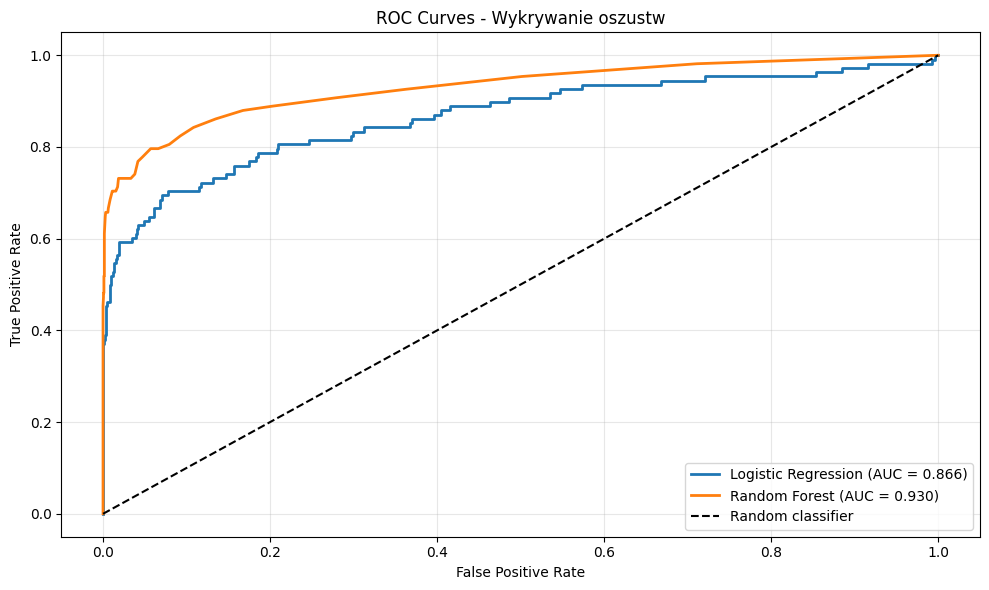

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt

# Generowanie syntetycznych danych (symulacja wykrywania oszustw)
np.random.seed(42)
X, y = make_classification(
n_samples=10000,
n_features=20,
n_informative=10,
n_redundant=5,
n_classes=2,
weights=[0.95, 0.05], # 5% fraudów - niezbalansowane!
random_state=42
)

print("="*60)
print("KLASYFIKACJA BINARNA - Wykrywanie oszustw")
print("="*60)
print(f"\nRozmiar danych: {X.shape}")
print(f"Rozkład klas:")
print(f" Klasa 0 (OK): {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")
print(f" Klasa 1 (Fraud): {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")

# Podział i preprocessing
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Trening dwóch modeli
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000,
random_state=42),
'Random Forest': RandomForestClassifier(n_estimators=100,
    random_state=42)
}

results = {}

for name, model in models.items():
    # Trening
    model.fit(X_train_scaled, y_train)
    # Predykcje
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    # Metryki
    roc_auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        'y_pred': y_pred,
        'y_proba': y_proba,
        'roc_auc': roc_auc,
        'cm': cm
    }

    print(f"\n{'='*40}")
    print(f"{name}")
    print(f"{'='*40}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"\nConfusion Matrix:")
    print(f" Predicted")
    print(f" OK Fraud")
    print(f"Actual OK {cm[0,0]:4d} {cm[0,1]:4d}")
    print(f" Fraud {cm[1,0]:4d} {cm[1,1]:4d}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['OK', 'Fraud']))

# Wizualizacja ROC Curves
fig, ax = plt.subplots(figsize=(10, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.3f})",
linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Wykrywanie oszustw')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Przykład 2: Klasyfikacja wieloklasowa - rozpoznawanie cyfr

KLASYFIKACJA WIELOKLASOWA - Rozpoznawanie cyfr

Rozmiar danych: (1797, 64)
Liczba klas: 10 (cyfry 0-9)
Rozmiar obrazka: 8x8 = 64 piksele (cechy)


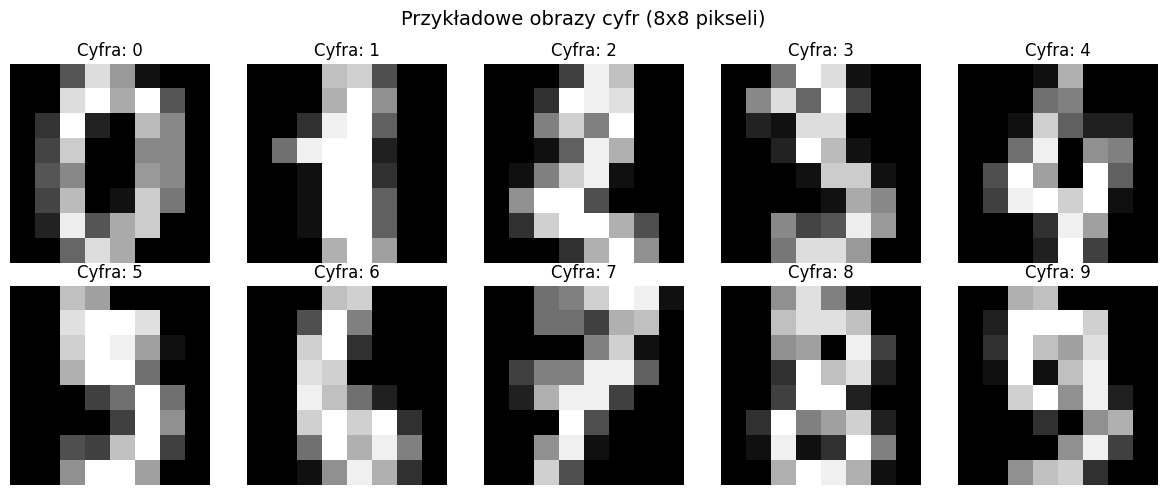


Accuracy: 0.9722

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.89      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.89      0.89      0.89        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ 

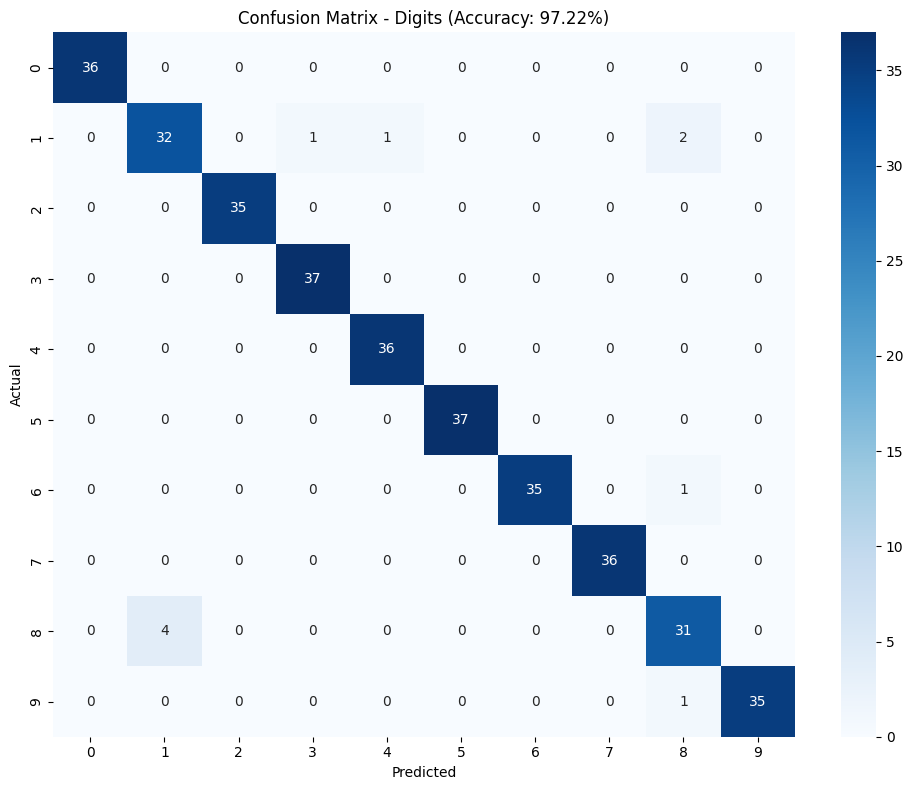


Liczba błędów: 10 z 360


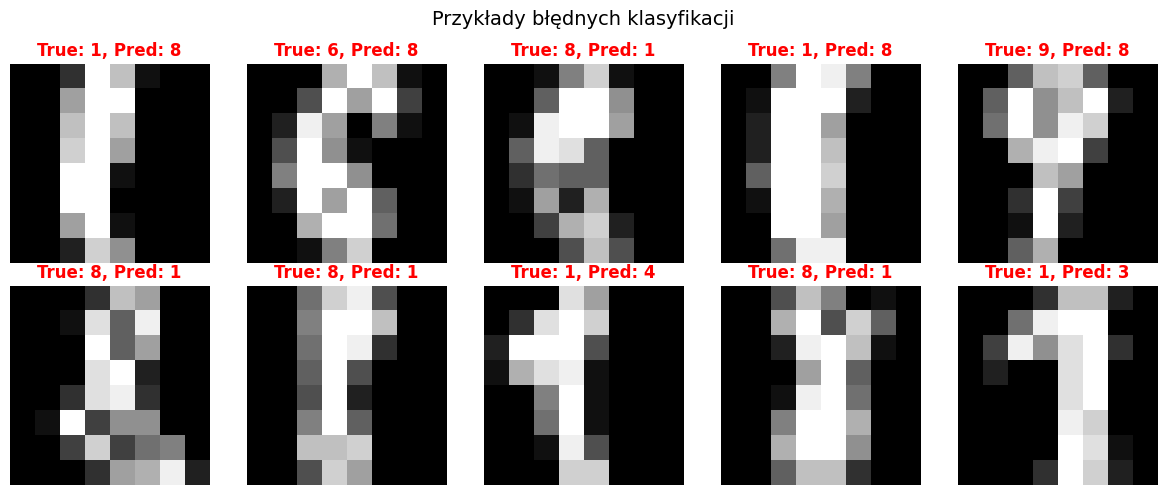

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Wczytanie datasetu MNIST (mała wersja - 8x8 pikseli)
digits = load_digits()
X, y = digits.data, digits.target

print("="*60)
print("KLASYFIKACJA WIELOKLASOWA - Rozpoznawanie cyfr")
print("="*60)
print(f"\nRozmiar danych: {X.shape}")
print(f"Liczba klas: {len(np.unique(y))} (cyfry 0-9)")
print(f"Rozmiar obrazka: 8x8 = 64 piksele (cechy)")

# Wizualizacja przykładowych cyfr
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Cyfra: {digits.target[i]}')
    ax.axis('off')
plt.suptitle('Przykładowe obrazy cyfr (8x8 pikseli)', fontsize=14)
plt.tight_layout()
plt.show()

# Podział i preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Trening modelu
model = LogisticRegression(max_iter=5000, random_state=42,
multi_class='multinomial')
model.fit(X_train_scaled, y_train)

# Predykcja
y_pred = model.predict(X_test_scaled)
accuracy = (y_pred == y_test).mean()

print(f"\nAccuracy: {accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=range(10), yticklabels=range(10))
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - Digits (Accuracy: {accuracy:.2%})')
plt.tight_layout()
plt.show()

# Przykłady błędnych predykcji
errors_idx = np.where(y_pred != y_test)[0]
print(f"\nLiczba błędów: {len(errors_idx)} z {len(y_test)}")
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    if i < len(errors_idx):
        idx = errors_idx[i]
        img = X_test[idx].reshape(8, 8)
        ax.imshow(img, cmap='gray')
        ax.set_title(f'True: {y_test[idx]}, Pred: {y_pred[idx]}', color='red', fontweight='bold')
    ax.axis('off')
plt.suptitle('Przykłady błędnych klasyfikacji', fontsize=14)
plt.tight_layout()
plt.show()

Przykład 3: Regresja - przewidywanie cen domów

REGRESJA - Przewidywanie cen domów w Kalifornii

Rozmiar danych: (20640, 8)
Cechy: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Statystyki celu (cena w $100k):
 Mean: 2.07
 Std: 1.15
 Min: 0.15
 Max: 5.00

Linear Regression:
 R² (train): 0.6126
 R² (test): 0.5758
 RMSE: 0.7456 ($100k)
 MAE: 0.5332 ($100k)

Ridge Regression:
 R² (train): 0.6126
 R² (test): 0.5758
 RMSE: 0.7456 ($100k)
 MAE: 0.5332 ($100k)


/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martus


Random Forest:
 R² (train): 0.9735
 R² (test): 0.8050
 RMSE: 0.5055 ($100k)
 MAE: 0.3276 ($100k)


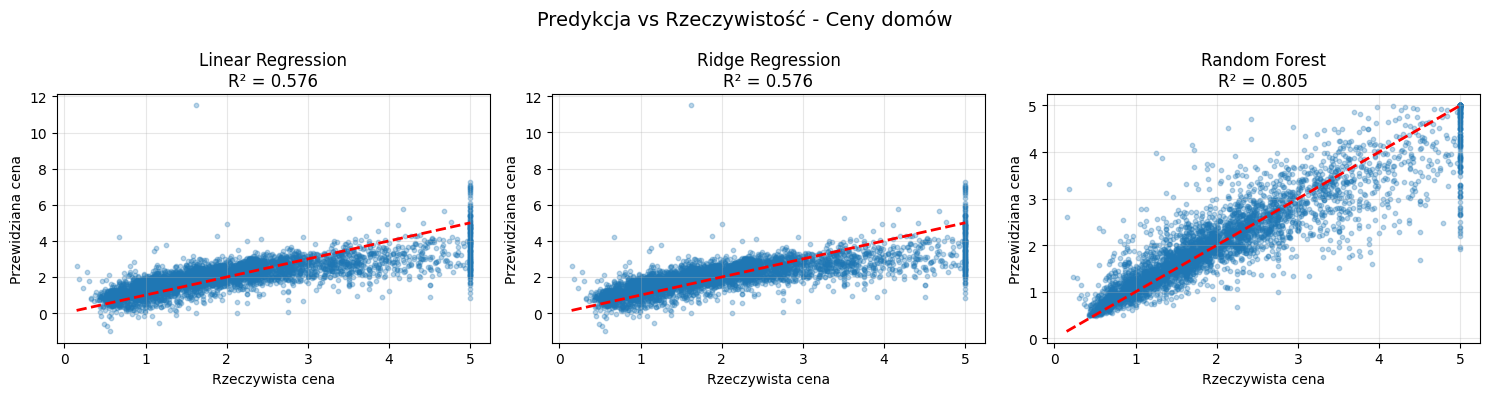

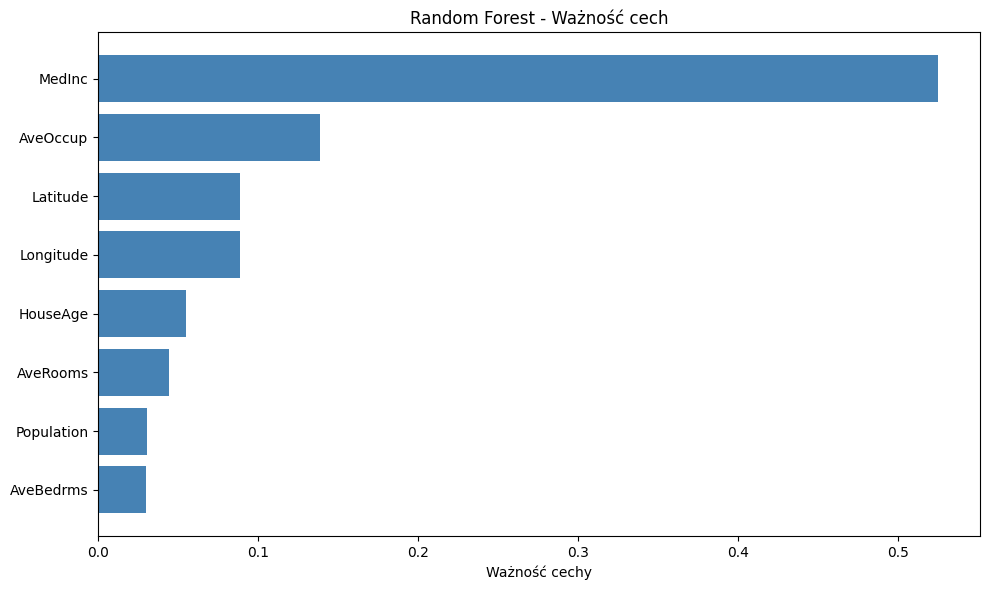

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Wczytanie danych
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print("="*60)
print("REGRESJA - Przewidywanie cen domów w Kalifornii")
print("="*60)
print(f"\nRozmiar danych: {X.shape}")
print(f"Cechy: {list(X.columns)}")
print(f"\nStatystyki celu (cena w $100k):")
print(f" Mean: {y.mean():.2f}")
print(f" Std: {y.std():.2f}")
print(f" Min: {y.min():.2f}")
print(f" Max: {y.max():.2f}")

# Podział i preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Trening i porównanie modeli
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100,
random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    # Trening
    model.fit(X_train_scaled, y_train)

    # Predykcja
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    # Metryki
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)

    results[name] = {
        'y_pred': y_pred_test,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'r2_train': r2_train
    }

    print(f"\n{name}:")
    print(f" R² (train): {r2_train:.4f}")
    print(f" R² (test): {r2:.4f}")
    print(f" RMSE: {rmse:.4f} ($100k)")
    print(f" MAE: {mae:.4f} ($100k)")

# Wizualizacja predykcji vs rzeczywistość
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    ax.scatter(y_test, res['y_pred'], alpha=0.3, s=10)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
    ax.set_xlabel('Rzeczywista cena')
    ax.set_ylabel('Przewidziana cena')
    ax.set_title(f'{name}\nR² = {res["r2"]:.3f}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Predykcja vs Rzeczywistość - Ceny domów', fontsize=14)
plt.tight_layout()
plt.show()

# Feature importance (dla Random Forest)
rf_model = models['Random Forest']
importance = pd.DataFrame({
    'feature': housing.feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance['feature'], importance['importance'], color='steelblue')
ax.set_xlabel('Ważność cechy')
ax.set_title('Random Forest - Ważność cech')
plt.tight_layout()
plt.show()

Metryki regresji:
MSE (Mean Squared Error) - średni błąd kwadratowy, penalizuje duże błędy
RMSE (Root MSE) - pierwiastek z MSE, w jednostkach celu
MAE (Mean Absolute Error) - średni błąd absolutny, bardziej odporny na outliers
R² (Coefficient of Determination) - procent wariancji wyjaśniony przez model (0-1,
wyżej = lepiej)

3. Uczenie nienadzorowane (Unsupervised Learning)

Uczenie nienadzorowane to paradygmat ML, w którym model uczy się na danych BEZ
etykiet. Celem jest odkrycie ukrytych struktur, wzorców lub grupowań w danych bez
wcześniejszej wiedzy o "prawidłowej odpowiedzi".

Typy zadań unsupervised learning

graph TD
A[Unsupervised Learning] --> B[Klasteryzacja]
A --> C[Redukcja wymiarowości]
A --> D[Wykrywanie anomalii]
A --> E[Association Rules]
B --> B1[k-Means]
B --> B2[DBSCAN]
B --> B3[Hierarchiczna]
C --> C1[PCA]
C --> C2[t-SNE]
C --> C3[UMAP]
D --> D1[Isolation Forest]
D --> D2[One-Class SVM]
E --> E1[Apriori]
E --> E2[FP-Growth]
style A fill:#9b59b6,color:#fff

Przykład 1: Klasteryzacja - segmentacja klientów

KLASTERYZACJA - Segmentacja klientów

Rozmiar danych: (500, 2)

Statystyki:
          Recency    Monetary
count  500.000000  500.000000
mean    -3.366574    2.893471
std      5.313279    6.358158
min    -10.739011   -8.649018
25%     -7.663072   -2.303335
50%     -4.871982    4.812360
75%     -0.215151    8.364306
max      9.258200   12.867018


/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

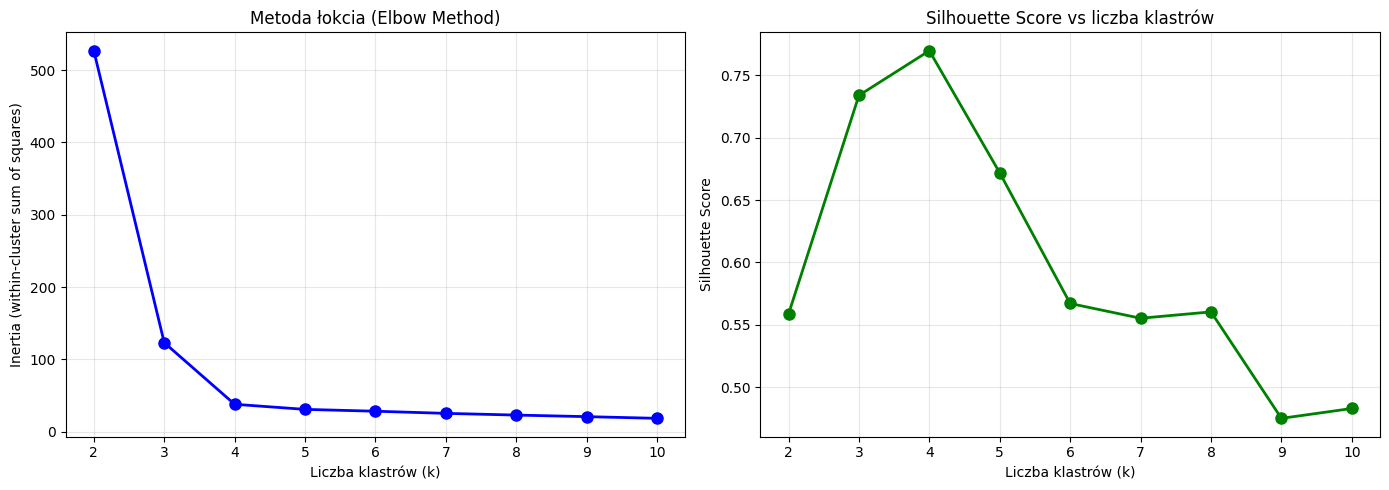

/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b



Optymalna liczba klastrów: 4
Silhouette Score: 0.770

Statystyki per klaster:
        Recency             Monetary      
           mean   std count     mean   std
Cluster                                   
0          4.76  1.59   125     1.90  1.37
1         -6.98  0.79   125    -6.90  0.81
2         -8.65  1.04   125     7.48  1.21
3         -2.60  0.93   125     9.09  1.02


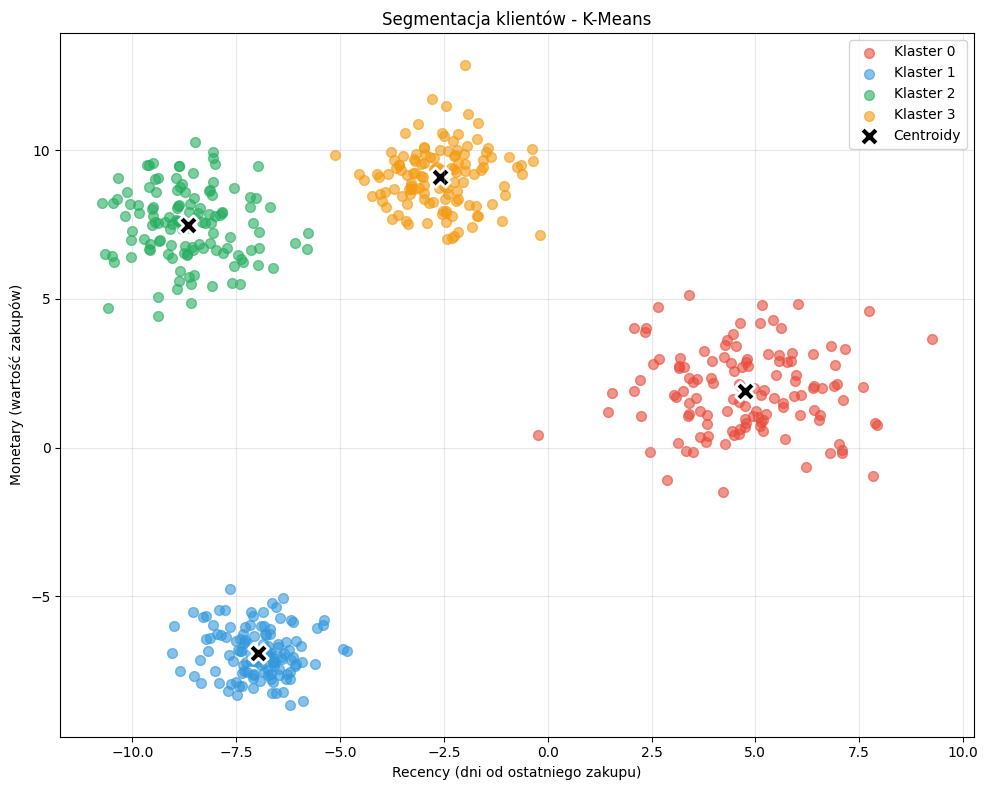

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

# Generowanie syntetycznych danych klientów
np.random.seed(42)
X, y_true = make_blobs(
    n_samples=500,
    n_features=2,
    centers=4,
    cluster_std=[1.0, 1.5, 0.8, 1.2],
    random_state=42
)

# Nadanie nazw cechom (symulacja RFM)
df = pd.DataFrame(X, columns=['Recency', 'Monetary'])

print("="*60)
print("KLASTERYZACJA - Segmentacja klientów")
print("="*60)
print(f"\nRozmiar danych: {df.shape}")
print(f"\nStatystyki:")
print(df.describe())

# Standaryzacja
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Metoda łokcia (Elbow method) - wybór liczby klastrów
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))

# Wizualizacja metody łokcia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Liczba klastrów (k)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Metoda łokcia (Elbow Method)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Liczba klastrów (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs liczba klastrów')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Finalna klasteryzacja z k=4
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print(f"\nOptymalna liczba klastrów: {k_optimal}")
print(f"Silhouette Score: {silhouette_score(X_scaled, clusters):.3f}")

# Statystyki per klaster
print(f"\nStatystyki per klaster:")
cluster_stats = df.groupby('Cluster').agg({
    'Recency': ['mean', 'std', 'count'],
    'Monetary': ['mean', 'std']
}).round(2)
print(cluster_stats)

# Wizualizacja klastrów
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#e74c3c', '#3498db', '#27ae60', '#f39c12']
for i in range(k_optimal):
    mask = clusters == i
    ax.scatter(df.loc[mask, 'Recency'], df.loc[mask, 'Monetary'], c=colors[i], label=f'Klaster {i}', alpha=0.6, s=50)

# Centroidy
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, edgecolors='white', linewidths=2, label='Centroidy')

ax.set_xlabel('Recency (dni od ostatniego zakupu)')
ax.set_ylabel('Monetary (wartość zakupów)')
ax.set_title('Segmentacja klientów - K-Means')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Przykład 2: Redukcja wymiarowości - PCA

REDUKCJA WYMIAROWOŚCI - PCA na cyfrach

Oryginalny rozmiar: (1797, 64) (64 cechy = 8x8 pikseli)


/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


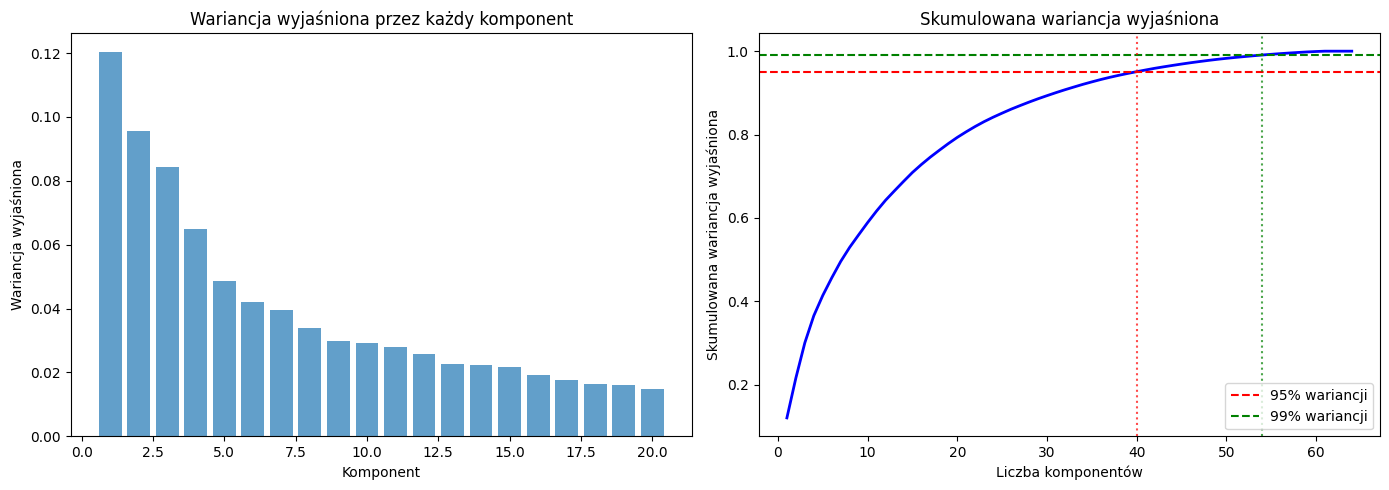


Komponentów dla 95% wariancji: 40
Komponentów dla 99% wariancji: 54

Po PCA do 2D: (1797, 2)
Wariancja wyjaśniona: 21.6%


/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packag

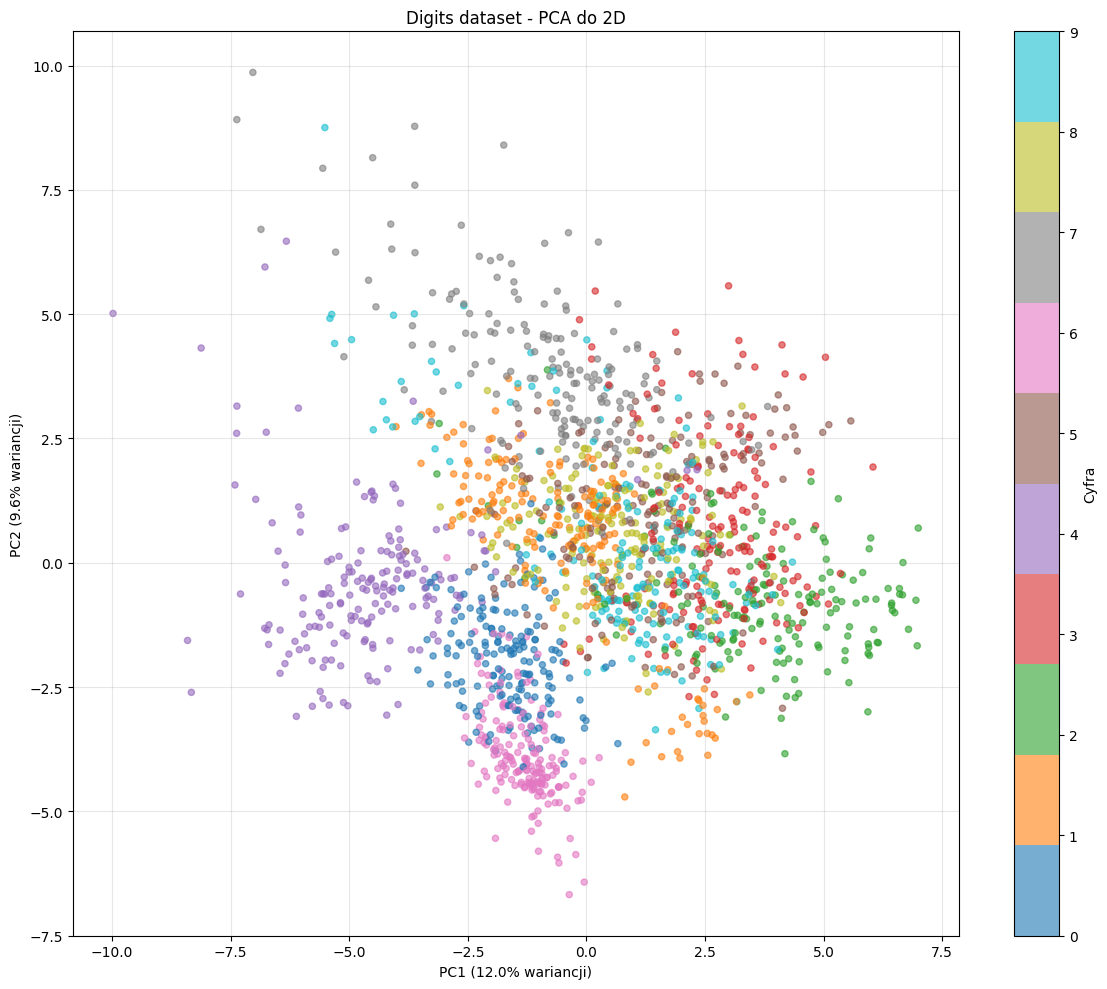

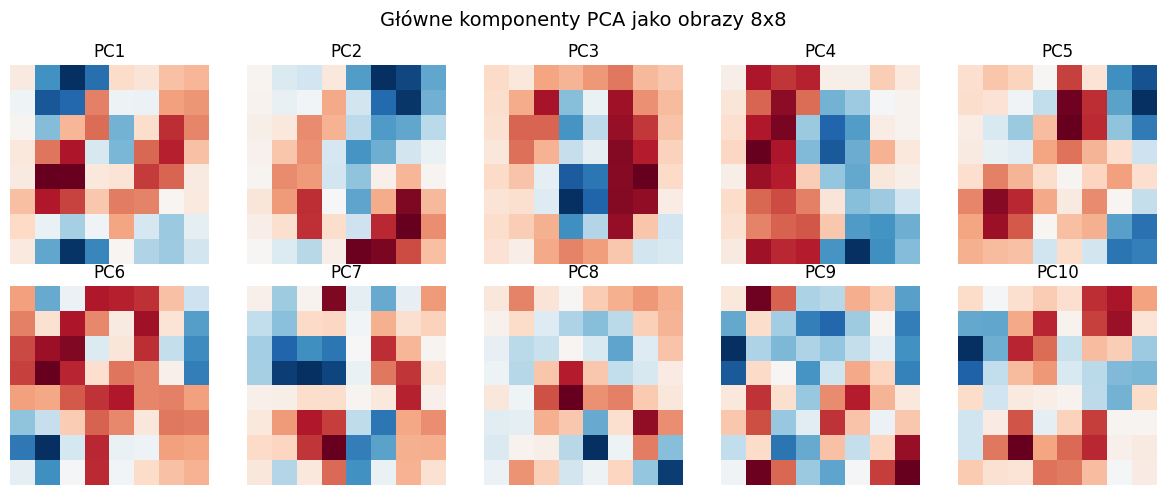

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Wczytanie danych
digits = load_digits()
X, y = digits.data, digits.target

print("="*60)
print("REDUKCJA WYMIAROWOŚCI - PCA na cyfrach")
print("="*60)
print(f"\nOryginalny rozmiar: {X.shape} (64 cechy = 8x8 pikseli)")

# Standaryzacja
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA z różną liczbą komponentów
pca_full = PCA()
pca_full.fit(X_scaled)

# Skumulowana wariancja wyjaśniona
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wariancja wyjaśniona per komponent
axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20], alpha=0.7)
axes[0].set_xlabel('Komponent')
axes[0].set_ylabel('Wariancja wyjaśniona')
axes[0].set_title('Wariancja wyjaśniona przez każdy komponent')

# Skumulowana wariancja
axes[1].plot(range(1, 65), cumsum_variance, 'b-', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% wariancji')
axes[1].axhline(y=0.99, color='g', linestyle='--', label='99% wariancji')
n_95 = np.argmax(cumsum_variance >= 0.95) + 1
n_99 = np.argmax(cumsum_variance >= 0.99) + 1
axes[1].axvline(x=n_95, color='r', linestyle=':', alpha=0.7)
axes[1].axvline(x=n_99, color='g', linestyle=':', alpha=0.7)
axes[1].set_xlabel('Liczba komponentów')
axes[1].set_ylabel('Skumulowana wariancja wyjaśniona')
axes[1].set_title('Skumulowana wariancja wyjaśniona')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nKomponentów dla 95% wariancji: {n_95}")
print(f"Komponentów dla 99% wariancji: {n_99}")

# PCA do 2D dla wizualizacji
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

print(f"\nPo PCA do 2D: {X_pca.shape}")
print(f"Wariancja wyjaśniona: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")

# Wizualizacja 2D
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.6, s=20)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% wariancji)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% wariancji)')
ax.set_title('Digits dataset - PCA do 2D')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cyfra')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wizualizacja głównych komponentów jako obrazy
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    if i < len(pca_full.components_):
        ax.imshow(pca_full.components_[i].reshape(8, 8), cmap='RdBu')
        ax.set_title(f'PC{i+1}')
    ax.axis('off')
plt.suptitle('Główne komponenty PCA jako obrazy 8x8', fontsize=14)
plt.tight_layout()
plt.show()

Przykład 3: Wykrywanie anomalii

WYKRYWANIE ANOMALII - Isolation Forest

Rozmiar danych: (320, 2)
Normalne: 300
Anomalie: 20

Confusion Matrix:
 Predicted
 Normal Anomaly
Actual Normal  288   12
 Anomaly    0   20

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98       300
     Anomaly       0.62      1.00      0.77        20

    accuracy                           0.96       320
   macro avg       0.81      0.98      0.87       320
weighted avg       0.98      0.96      0.97       320



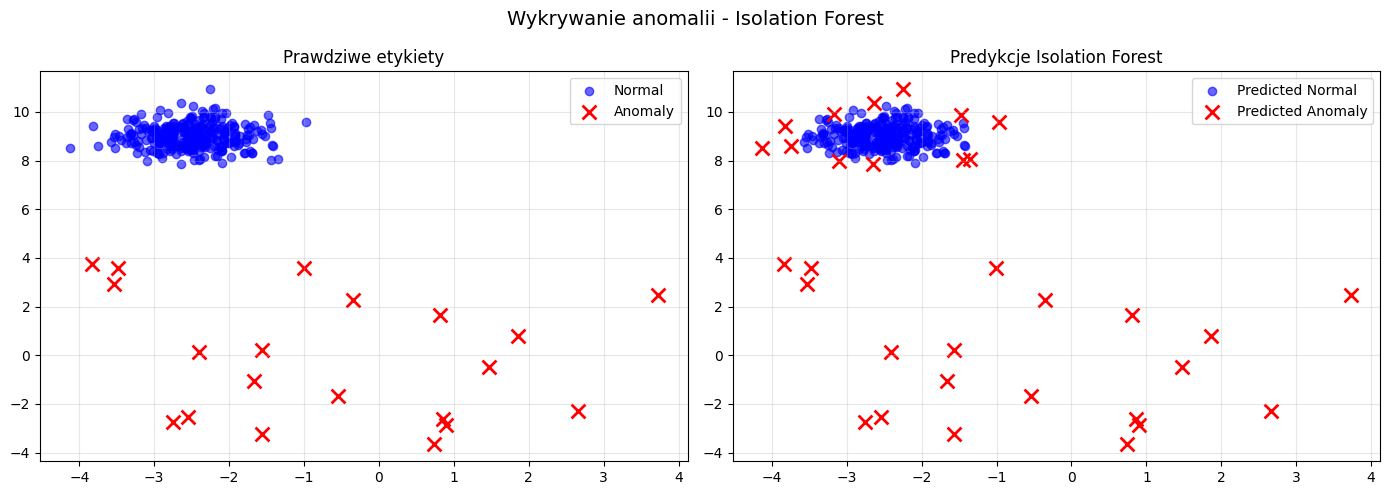

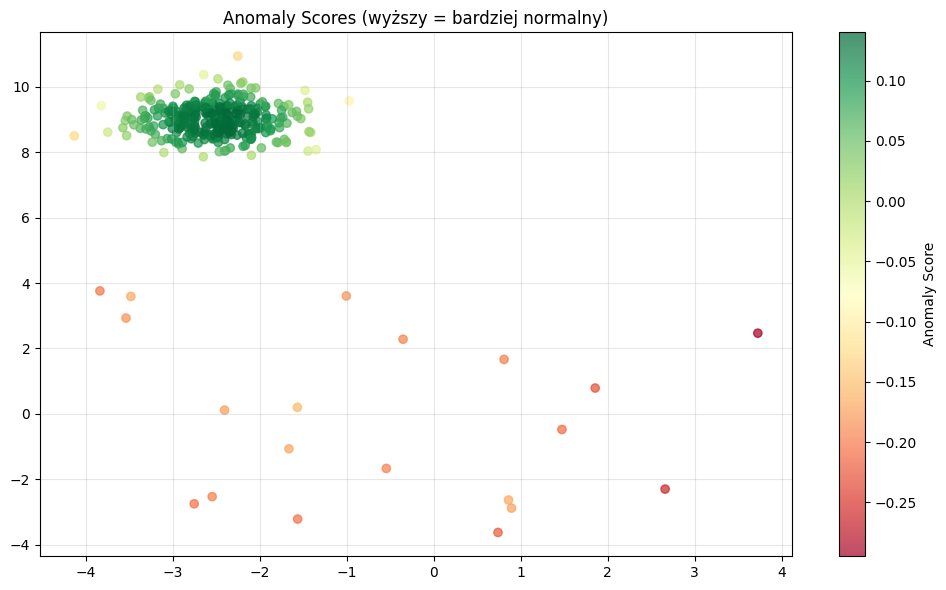

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Generowanie danych z anomaliami
np.random.seed(42)

# Normalne dane
X_normal, _ = make_blobs(n_samples=300, centers=1, cluster_std=0.5,
random_state=42)

# Anomalie (outliers)
n_outliers = 20
X_outliers = np.random.uniform(low=-4, high=4, size=(n_outliers, 2))

# Łączenie
X = np.vstack([X_normal, X_outliers])
y_true = np.array([0] * len(X_normal) + [1] * n_outliers) # 0 = normal, 1 = anomaly

print("="*60)
print("WYKRYWANIE ANOMALII - Isolation Forest")
print("="*60)
print(f"\nRozmiar danych: {X.shape}")
print(f"Normalne: {len(X_normal)}")
print(f"Anomalie: {n_outliers}")

# Standaryzacja
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.1, # oczekiwany % anomalii
    random_state=42
)

# Predykcja: -1 = anomaly, 1 = normal
y_pred = iso_forest.fit_predict(X_scaled)
anomaly_scores = iso_forest.decision_function(X_scaled)

# Konwersja na 0/1
y_pred_binary = (y_pred == -1).astype(int)

# Ewaluacja
from sklearn.metrics import confusion_matrix, classification_report

print(f"\nConfusion Matrix:") 
cm = confusion_matrix(y_true, y_pred_binary)
print(f" Predicted")
print(f" Normal Anomaly")
print(f"Actual Normal {cm[0,0]:4d} {cm[0,1]:4d}")
print(f" Anomaly {cm[1,0]:4d} {cm[1,1]:4d}")
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred_binary, target_names=['Normal', 'Anomaly']))

# Wizualizacja
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lewy: True labels
ax1 = axes[0]
ax1.scatter(X[y_true == 0, 0], X[y_true == 0, 1], c='blue', label='Normal', alpha=0.6)
ax1.scatter(X[y_true == 1, 0], X[y_true == 1, 1], c='red', label='Anomaly', marker='x', s=100, linewidths=2)
ax1.set_title('Prawdziwe etykiety')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Prawy: Predicted
ax2 = axes[1]
ax2.scatter(X[y_pred == 1, 0], X[y_pred == 1, 1], c='blue', label='Predicted Normal', alpha=0.6)
ax2.scatter(X[y_pred == -1, 0], X[y_pred == -1, 1], c='red', label='Predicted Anomaly', marker='x', s=100, linewidths=2)
ax2.set_title('Predykcje Isolation Forest')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Wykrywanie anomalii - Isolation Forest', fontsize=14)
plt.tight_layout()
plt.show()

# Wizualizacja anomaly scores
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(X[:, 0], X[:, 1], c=anomaly_scores, cmap='RdYlGn',
alpha=0.7)
ax.set_title('Anomaly Scores (wyższy = bardziej normalny)')
plt.colorbar(scatter, ax=ax, label='Anomaly Score')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Note
Kiedy używać unsupervised learning:
Nie mamy etykiet (brak "ground truth")
Chcemy odkryć strukturę w danych
Segmentacja klientów, grupowanie dokumentów
Redukcja wymiarowości przed wizualizacją lub modelowaniem
Wykrywanie anomalii (rzadkie zdarzenia)

4. Walidacja i generalizacja

Definition
Generalizacja to zdolność modelu do poprawnego działania na nowych, niewidzianych
wcześniej danych. Dobry model nie tylko "zapamiętuje" dane treningowe, ale uczy się
ogólnych wzorców.

Overfitting vs Underfitting

graph LR
A[Model] --> B{Złożoność}
B -->|Za prosta| C[Underfitting]
B -->|Optymalna| D[Good Fit]
B -->|Za złożona| E[Overfitting]
C --> C1[Wysoki błąd train]
C --> C2[Wysoki błąd test]
D --> D1[Niski błąd train]
D --> D2[Niski błąd test]
E --> E1[Bardzo niski błąd train]
E --> E2[Wysoki błąd test]
style C fill:#e74c3c,color:#fff
style D fill:#27ae60,color:#fff
style E fill:#e74c3c,color:#fff

Przykład 1: Demonstracja overfitting/underfitting

/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


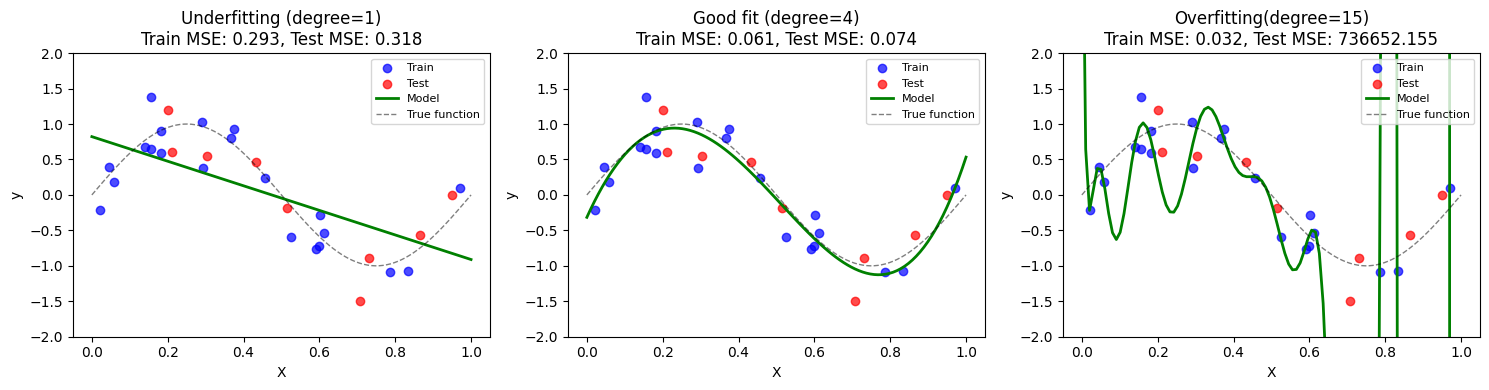

Interpretacja:
- Underfitting: Model zbyt prosty, nie łapie wzorca (wysoki błąd train i test)
- Good fit: Model odpowiednio złożony (niski błąd train i test)
- Overfitting: Model zbyt złożony, zapamiętał szum (bardzo niski train, wysoki test)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Generowanie danych z szumem
np.random.seed(42)
n_samples = 30

X = np.sort(np.random.uniform(0, 1, n_samples))
y = np.sin(2 * np.pi * X) + np.random.normal(0, 0.3, n_samples)

X = X.reshape(-1, 1)

# Podział na train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Porównanie różnych stopni wielomianu
degrees = [1, 4, 15]
titles = ['Underfitting (degree=1)', 'Good fit (degree=4)', 'Overfitting(degree=15)']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

X_plot = np.linspace(0, 1, 100).reshape(-1, 1)

for ax, degree, title in zip(axes, degrees, titles):
    # Pipeline: polynomial features + linear regression
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])

    model.fit(X_train, y_train)

    # Predykcje
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_plot = model.predict(X_plot)

    # Metryki
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Wizualizacja
    ax.scatter(X_train, y_train, c='blue', label='Train', alpha=0.7)
    ax.scatter(X_test, y_test, c='red', label='Test', alpha=0.7)
    ax.plot(X_plot, y_plot, 'g-', linewidth=2, label='Model')
    ax.plot(X_plot, np.sin(2 * np.pi * X_plot), 'k--', linewidth=1, label='True function', alpha=0.5)

    ax.set_title(f'{title}\nTrain MSE: {train_mse:.3f}, Test MSE: {test_mse:.3f}')
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylim(-2, 2)

plt.tight_layout()
plt.show()

print("Interpretacja:")
print("- Underfitting: Model zbyt prosty, nie łapie wzorca (wysoki błąd train i test)")
print("- Good fit: Model odpowiednio złożony (niski błąd train i test)")
print("- Overfitting: Model zbyt złożony, zapamiętał szum (bardzo niski train, wysoki test)")

Przykład 2: Walidacja krzyżowa (Cross-Validation)

WALIDACJA KRZYŻOWA (Cross-Validation)

Logistic Regression:
 Scores per fold: [1.         0.96666667 0.93333333 1.         0.93333333]
 Mean: 0.9667
 Std: 0.0298
 95% CI: [0.9082, 1.0251]

Decision Tree:
 Scores per fold: [1.         0.96666667 0.93333333 0.96666667 0.9       ]
 Mean: 0.9533
 Std: 0.0340
 95% CI: [0.8867, 1.0200]

Random Forest:
 Scores per fold: [0.96666667 0.96666667 0.93333333 0.96666667 0.9       ]
 Mean: 0.9467
 Std: 0.0267
 95% CI: [0.8944, 0.9989]


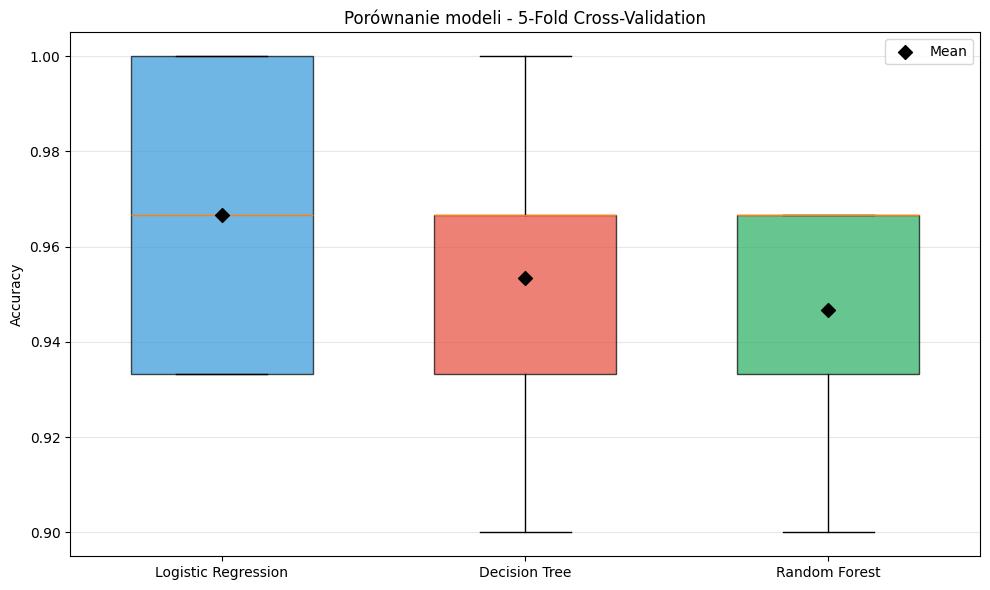

In [12]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Wczytanie danych
iris = load_iris()
X, y = iris.data, iris.target

print("="*60)
print("WALIDACJA KRZYŻOWA (Cross-Validation)")
print("="*60)

# Różne modele do porównania
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100,
random_state=42)
}

# 5-fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results[name] = scores

    print(f"\n{name}:")
    print(f" Scores per fold: {scores}")
    print(f" Mean: {scores.mean():.4f}")
    print(f" Std: {scores.std():.4f}")
    print(f" 95% CI: [{scores.mean() - 1.96*scores.std():.4f}, "f"{scores.mean() + 1.96*scores.std():.4f}]")

# Wizualizacja porównania
fig, ax = plt.subplots(figsize=(10, 6))

positions = np.arange(len(models))
bp = ax.boxplot([results[name] for name in models.keys()], positions=positions, widths=0.6, patch_artist=True)

colors = ['#3498db', '#e74c3c', '#27ae60']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(models.keys())
ax.set_ylabel('Accuracy')
ax.set_title('Porównanie modeli - 5-Fold Cross-Validation')
ax.grid(True, alpha=0.3, axis='y')

# Dodaj średnie jako punkty
means = [results[name].mean() for name in models.keys()]
ax.scatter(positions, means, c='black', marker='D', s=50, zorder=3, label='Mean')
ax.legend()

plt.tight_layout()
plt.show()

Przykład 3: Learning Curves - diagnoza over/underfitting

/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/martusia/Des

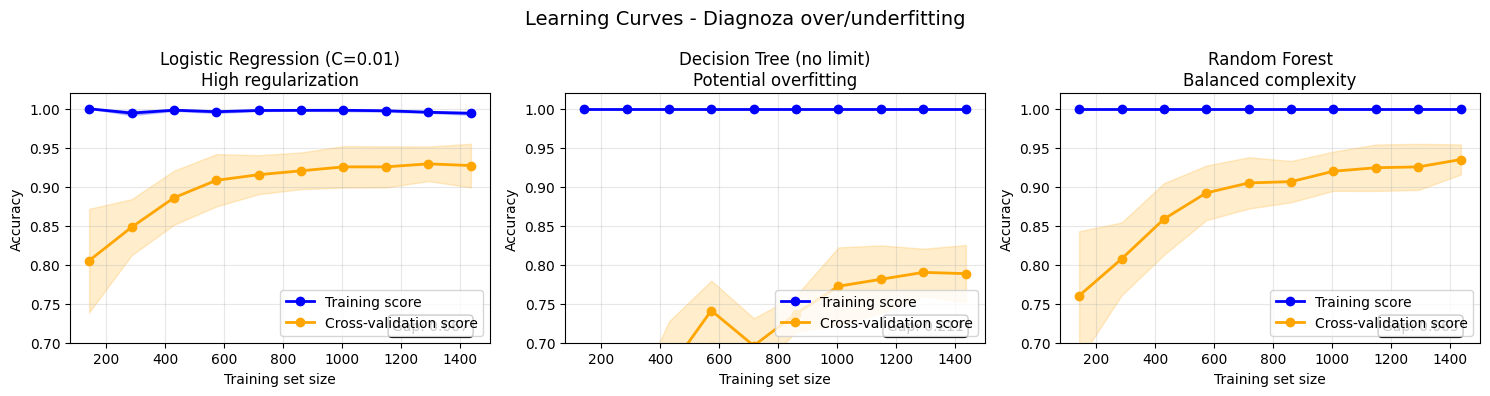


Interpretacja Learning Curves:
--------------------------------------------------
• Obie krzywe nisko → Underfitting (model za prosty)
• Duży gap między krzywymi → Overfitting (model za złożony)
• Obie krzywe wysoko, mały gap → Dobry model
• Krzywe zbiegają się z większą ilością danych → Więcej danych pomoże


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Wczytanie danych
digits = load_digits()
X, y = digits.data, digits.target

def plot_learning_curve(estimator, title, X, y, ax, cv=5):
    """Rysuje learning curve dla danego estymatora"""

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y,
        cv=cv,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy',
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    test_mean = test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)

    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='orange')

    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score', linewidth=2)
    ax.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-validation score', linewidth=2)

    ax.set_xlabel('Training set size')
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.7, 1.02)

    # Diagnoza
    gap = train_mean[-1] - test_mean[-1]
    return gap

# Porównanie modeli
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    (LogisticRegression(max_iter=5000, C=0.01), 'Logistic Regression (C=0.01)\nHigh regularization'),
    (DecisionTreeClassifier(max_depth=None, random_state=42), 'Decision Tree (no limit)\nPotential overfitting'),
    (RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42), 'Random Forest\nBalanced complexity')
]

for ax, (model, title) in zip(axes, models):
    gap = plot_learning_curve(model, title, X, y, ax)
    ax.annotate(f'Gap: {gap:.3f}', xy=(0.95, 0.05), xycoords='axes fraction', ha='right', fontsize=10, bbox=dict(boxstyle='round', facecolor='white'))

plt.suptitle('Learning Curves - Diagnoza over/underfitting', fontsize=14)
plt.tight_layout()
plt.show()

print("\nInterpretacja Learning Curves:")
print("-" * 50)
print("• Obie krzywe nisko → Underfitting (model za prosty)")
print("• Duży gap między krzywymi → Overfitting (model za złożony)")
print("• Obie krzywe wysoko, mały gap → Dobry model")
print("• Krzywe zbiegają się z większą ilością danych → Więcej danych pomoże")

Success

Strategie rozwiązania problemów:

Underfitting:
- Zwiększ złożoność modelu
- Dodaj więcej cech (feature engineering)
- Zmniejsz regularyzację

Overfitting:
- Zmniejsz złożoność modelu
- Dodaj regularyzację (L1, L2)
- Zbierz więcej danych
- Zastosuj dropout, early stopping

5. Wybór odpowiedniego algorytmu

Mapa decyzyjna sklearn

graph TD
A[Start] --> B{Masz etykiety?}
B -->|Tak| C{Typ problemu?}
B -->|Nie| D{Cel?}
C -->|Klasyfikacja| E{Ile danych?}
C -->|Regresja| F{Ile danych?}
E -->|< 100k| G[SVM, Random Forest]
E -->|> 100k| H[SGD Classifier, Neural Net]
F -->|< 100k| I[Ridge, Lasso, SVR]
F -->|> 100k| J[SGD Regressor]
D -->|Grupowanie| K[K-Means, DBSCAN]
D -->|Redukcja wymiarów| L[PCA, t-SNE]
D -->|Anomalie| M[Isolation Forest]
style B fill:#f39c12,color:#fff
style C fill:#3498db,color:#fff
style D fill:#9b59b6,color:#fff

Przykład: Porównanie algorytmów na różnych datasetach

PORÓWNANIE ALGORYTMÓW NA RÓŻNYCH DATASETACH

Accuracy (5-fold CV):
                     Liniowo separowalne  Moons (nieliniowe)  \
Logistic Regression                0.927               0.870   
Decision Tree                      0.933               0.937   
Random Forest                      0.957               0.947   
k-NN (k=5)                         0.957               0.950   
SVM (RBF)                          0.957               0.923   
Gradient Boosting                  0.950               0.943   

                     Circles (koncentryczne)  
Logistic Regression                    0.473  
Decision Tree                          0.960  
Random Forest                          0.980  
k-NN (k=5)                             0.990  
SVM (RBF)                              0.990  
Gradient Boosting                      0.967  


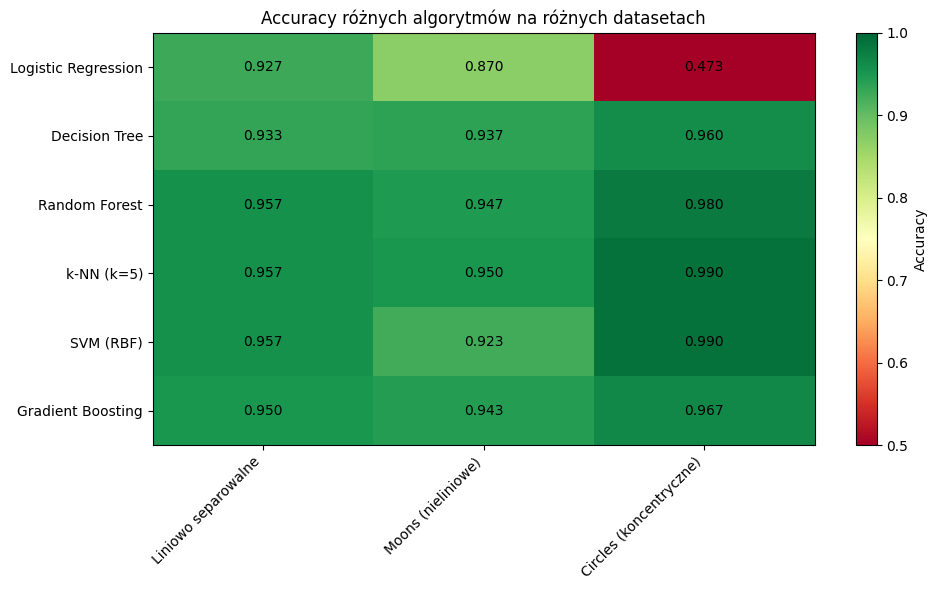

/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

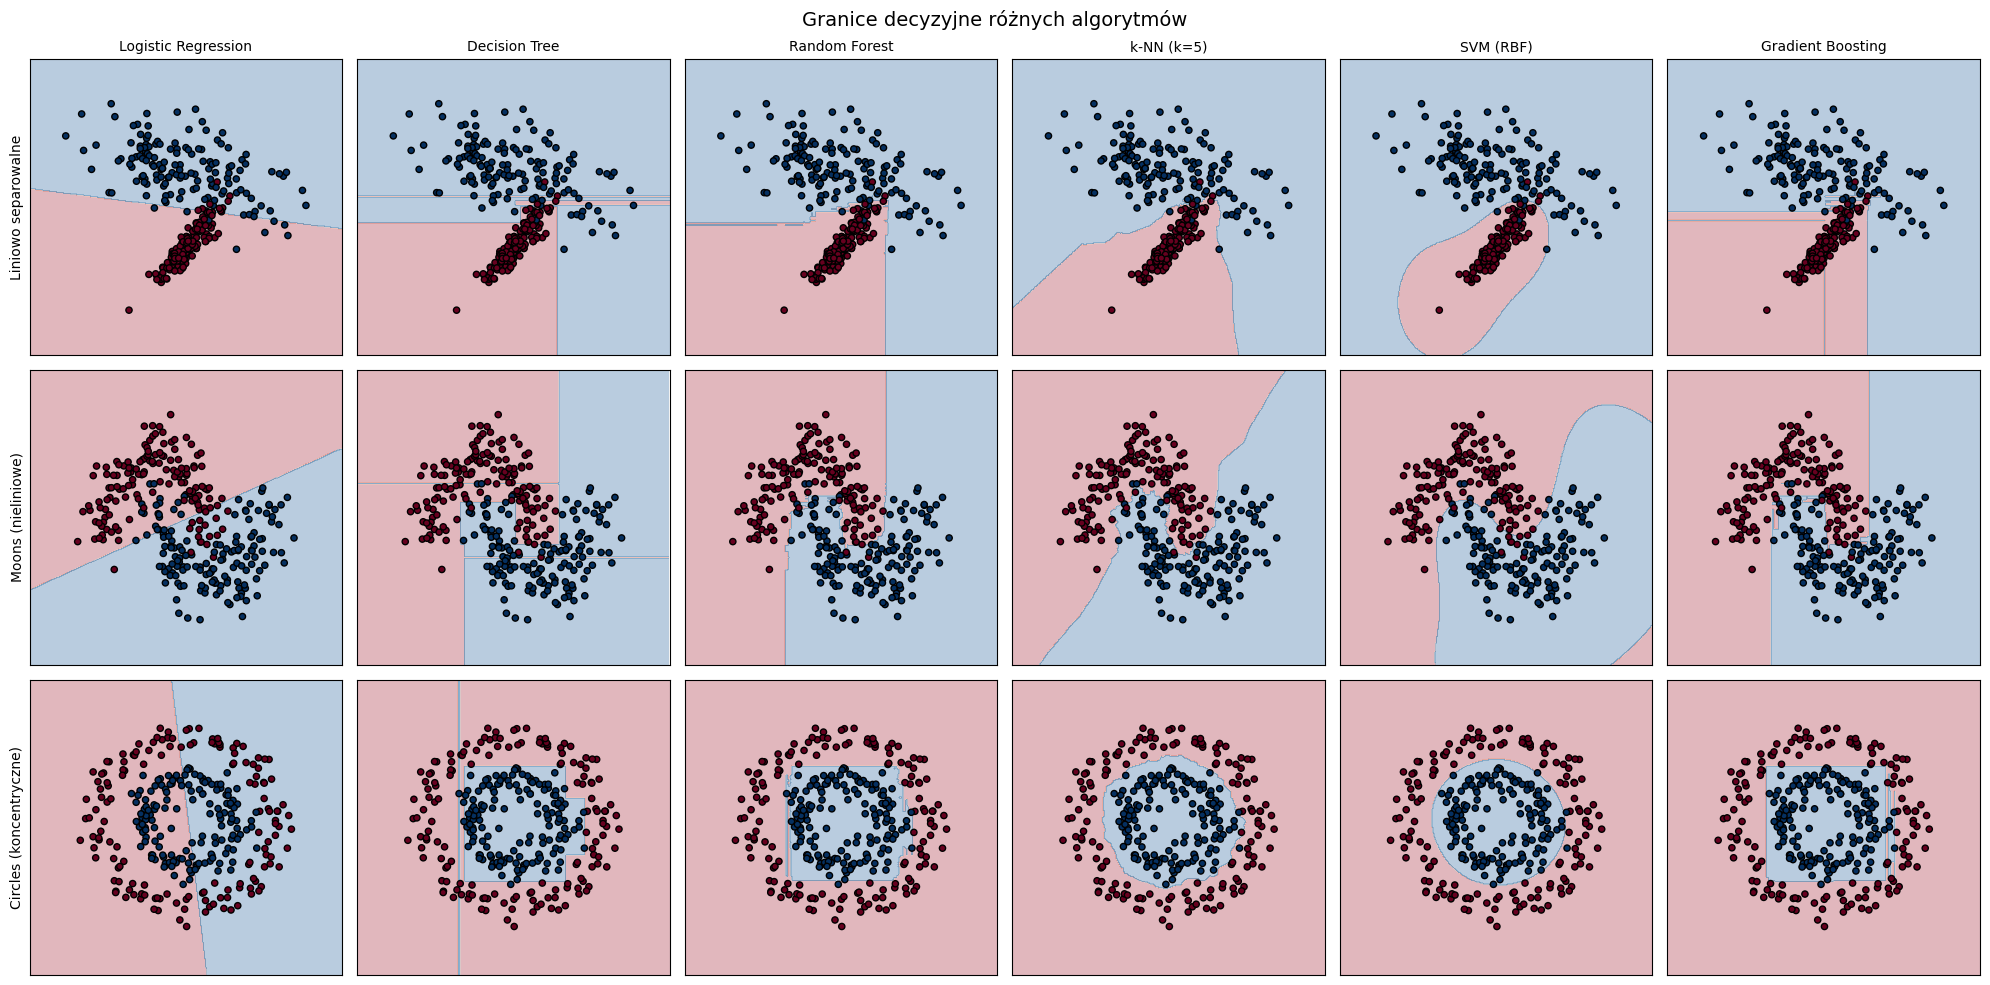

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Generowanie różnych typów datasetów
datasets = {
    'Liniowo separowalne': make_classification(
        n_samples=300, n_features=2, n_redundant=0, n_informative=2,
        n_clusters_per_class=1, random_state=42
    ),
    'Moons (nieliniowe)': make_moons(n_samples=300, noise=0.2, 
random_state=42),
    'Circles (koncentryczne)': make_circles(n_samples=300, noise=0.1,
factor=0.5, random_state=42)
}

# Modele do porównania
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100,
random_state=42),
    'k-NN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(kernel='rbf', gamma='scale'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100,
random_state=42)
}

# Ewaluacja
results = {}

for ds_name, (X, y) in datasets.items():
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    results[ds_name] = {}

    for model_name, model in models.items():
        scores = cross_val_score(model, X_scaled, y, cv=5,
scoring='accuracy')
        results[ds_name][model_name] = scores.mean()

# Tworzenie DataFrame z wynikami
results_df = pd.DataFrame(results)
print("="*60)
print("PORÓWNANIE ALGORYTMÓW NA RÓŻNYCH DATASETACH")
print("="*60)
print(f"\nAccuracy (5-fold CV):")
print(results_df.round(3))

# Wizualizacja heatmap
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(results_df.values, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=1.0)

ax.set_xticks(np.arange(len(results_df.columns)))
ax.set_yticks(np.arange(len(results_df.index)))
ax.set_xticklabels(results_df.columns)
ax.set_yticklabels(results_df.index)

plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

for i in range(len(results_df.index)):
    for j in range(len(results_df.columns)):
        text = ax.text(j, i, f'{results_df.iloc[i, j]:.3f}', 
                        ha='center', va='center', color='black')

ax.set_title('Accuracy różnych algorytmów na różnych datasetach')
plt.colorbar(im, ax=ax, label='Accuracy')
plt.tight_layout()
plt.show()

# Wizualizacja granic decyzyjnych
fig, axes = plt.subplots(3, 6, figsize=(20, 10))

for row, (ds_name, (X, y)) in enumerate(datasets.items()):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    for col, (model_name, model) in enumerate(models.items()):
        ax = axes[row, col]

        # Trening
        model.fit(X_scaled, y)

        # Siatka do wizualizacji granic
        h = 0.02
        x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
        y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
        ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='RdBu', edgecolors='black', s=20)

        if row == 0:
            ax.set_title(model_name, fontsize=10)
        if col == 0:
            ax.set_ylabel(ds_name, fontsize=10)

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Granice decyzyjne różnych algorytmów', fontsize=14)
plt.tight_layout()
plt.show()

Praktyczne wskazówki wyboru algorytmu:

Sytuacja: Rekomendacja
Pierwszy baseline:             Logistic Regression / Ridge
Potrzebuję interpretowalności: Decision Tree, Linear models
Dużo danych (>100k):           Gradient Boosting, Neural Nets
Mało danych SVM, k-NN:
Dane nieliniowe:               Random Forest, SVM (RBF), Neural Nets

Sytuacja: Rekomendacja
Szybki trening:  Decision Tree, k-NN
Wysoka dokładność: Gradient Boosting, Random Forest

Wpływ modeli ML na zużycie energii:

- Prosty model -> Niskie zużycie -> Linear Regression, Decision Tree
- Złożony model -> Wysokie zużycie -> Deep Learning, Ensemble 1000+ drzew


Przykład: Porównanie efektywności modeli

PORÓWNANIE EFEKTYWNOŚCI MODELI (Green IT)
Logistic Regression       | Acc: 0.8658 | Time: 0.01s | Eff: 151.7076
Decision Tree             | Acc: 0.8818 | Time: 0.09s | Eff: 9.7262
Random Forest (10)        | Acc: 0.9026 | Time: 0.15s | Eff: 6.0127
Random Forest (100)       | Acc: 0.9094 | Time: 1.42s | Eff: 0.6406
Gradient Boosting (50)    | Acc: 0.9092 | Time: 1.72s | Eff: 0.5288
Gradient Boosting (200)   | Acc: 0.9104 | Time: 6.84s | Eff: 0.1331
MLP (small)               | Acc: 0.8488 | Time: 3.80s | Eff: 0.2237
MLP (large)               | Acc: 0.8266 | Time: 2.42s | Eff: 0.3413


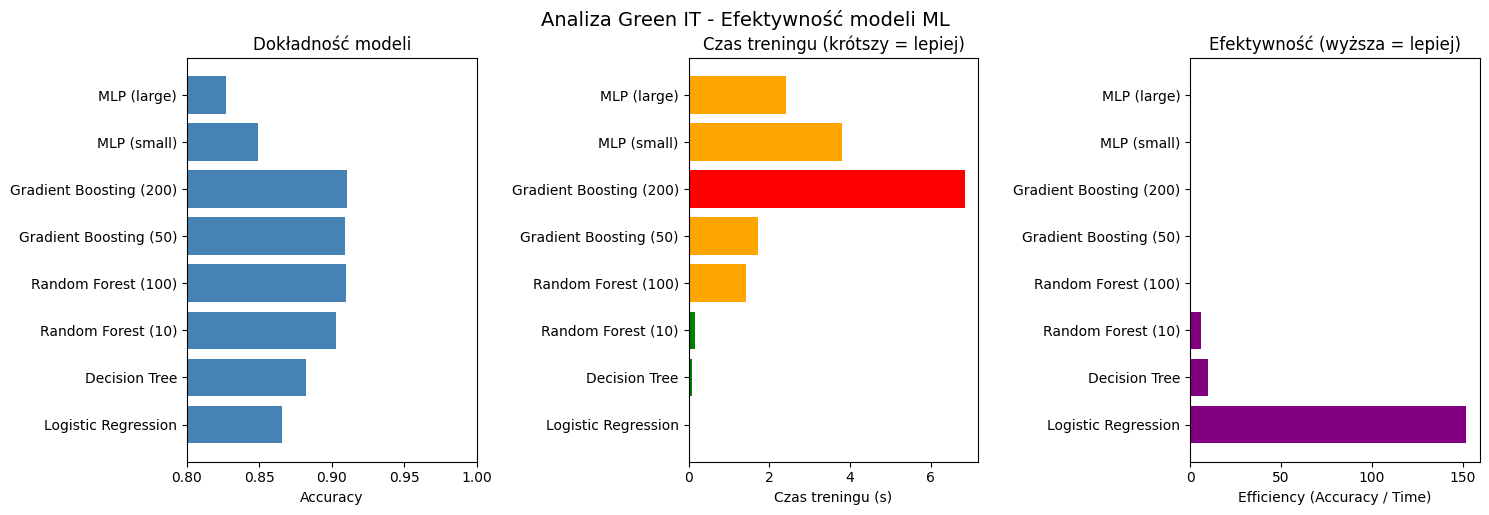


REKOMENDACJE GREEN IT

✅ Najbardziej efektywny: Logistic Regression
 Accuracy: 0.8658
 Czas: 0.01s

⚡ Najszybszy: Logistic Regression
 Accuracy: 0.8658
 Czas: 0.01s

🎯 Najdokładniejszy: Gradient Boosting (200)
 Accuracy: 0.9104
 Czas: 6.84s


In [12]:
import numpy as np
import time
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# Generowanie danych
X, y = make_classification(n_samples=5000, n_features=20, random_state=42)

# Modele do porównania
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=10),
    'Random Forest (10)': RandomForestClassifier(n_estimators=10,
random_state=42),
    'Random Forest (100)': RandomForestClassifier(n_estimators=100,
random_state=42),
    'Gradient Boosting (50)': GradientBoostingClassifier(n_estimators=50,
random_state=42),
    'Gradient Boosting (200)': GradientBoostingClassifier(n_estimators=200,
random_state=42),
    'MLP (small)': MLPClassifier(hidden_layer_sizes=(50,), max_iter=500,
random_state=42),
    'MLP (large)': MLPClassifier(hidden_layer_sizes=(100, 50, 25),
max_iter=500, random_state=42)
}

results = []

print("="*60)
print("PORÓWNANIE EFEKTYWNOŚCI MODELI (Green IT)")
print("="*60)

for name, model in models.items():
    # Pomiar czasu treningu
    start_time = time.time()
    scores = cross_val_score(model, X, y, cv=3, scoring='accuracy')
    train_time = time.time() - start_time

    accuracy = scores.mean()

    # Efficiency ratio: accuracy / time
    efficiency = accuracy / train_time if train_time > 0 else 0

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Time (s)': train_time,
        'Efficiency': efficiency
    })

    print(f"{name:25s} | Acc: {accuracy:.4f} | Time: {train_time:.2f}s | Eff: {efficiency:.4f}")

# Wizualizacja
import pandas as pd
results_df = pd.DataFrame(results)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Accuracy
axes[0].barh(results_df['Model'], results_df['Accuracy'], color='steelblue')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Dokładność modeli')
axes[0].set_xlim(0.8, 1.0)

# Time
colors = ['green' if t < 1 else 'orange' if t < 5 else 'red' for t in
results_df['Time (s)']]
axes[1].barh(results_df['Model'], results_df['Time (s)'], color=colors)
axes[1].set_xlabel('Czas treningu (s)')
axes[1].set_title('Czas treningu (krótszy = lepiej)')

# Efficiency
axes[2].barh(results_df['Model'], results_df['Efficiency'], color='purple')
axes[2].set_xlabel('Efficiency (Accuracy / Time)')
axes[2].set_title('Efektywność (wyższa = lepiej)')

plt.tight_layout()
plt.suptitle('Analiza Green IT - Efektywność modeli ML', y=1.02,
fontsize=14)
plt.show()

# Rekomendacje
print("\n" + "="*60)
print("REKOMENDACJE GREEN IT")
print("="*60)

best_efficiency = results_df.loc[results_df['Efficiency'].idxmax()]
print(f"\n✅ Najbardziej efektywny: {best_efficiency['Model']}")
print(f" Accuracy: {best_efficiency['Accuracy']:.4f}")
print(f" Czas: {best_efficiency['Time (s)']:.2f}s")

fastest = results_df.loc[results_df['Time (s)'].idxmin()]
print(f"\n⚡ Najszybszy: {fastest['Model']}")
print(f" Accuracy: {fastest['Accuracy']:.4f}")
print(f" Czas: {fastest['Time (s)']:.2f}s")

most_accurate = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"\n🎯 Najdokładniejszy: {most_accurate['Model']}")
print(f" Accuracy: {most_accurate['Accuracy']:.4f}")
print(f" Czas: {most_accurate['Time (s)']:.2f}s")

In [9]:
# DOBRE PRAKTYKI - oszczędzanie zasobów
# 1. Zacznij od prostych modeli
from sklearn.linear_model import LogisticRegression
baseline = LogisticRegression() # Szybki, efektywny baseline

# 2. Używaj mniej drzew w Random Forest (często 50-100 wystarczy)
from sklearn.ensemble import RandomForestClassifier
rf_efficient = RandomForestClassifier(n_estimators=50) # zamiast 500

# 3. Ogranicz głębokość drzew
rf_limited = RandomForestClassifier(n_estimators=100, max_depth=10)

# 4. Używaj n_jobs=-1 dla parallelizacji (szybciej = mniej energii)
rf_parallel = RandomForestClassifier(n_estimators=100, n_jobs=-1)

# 5. Early stopping w Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
gb_early = GradientBoostingClassifier(n_estimators=500, n_iter_no_change=10)

# 6. Próbkowanie danych podczas eksperymentów
from sklearn.model_selection import train_test_split
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=0.1,
random_state=42)
# Testuj na próbce, finalne trenowanie na całości

# 7. Redukcja wymiarowości przed trenowaniem
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95) # zachowaj 95% wariancji
X_reduced = pca.fit_transform(X)

print("Green ML Best Practices:")
print("1. Zacznij od prostych modeli (baseline)")
print("2. Ogranicz liczbę estymatorów w ensemblach")
print("3. Używaj max_depth dla drzew")
print("4. Parallelizuj (n_jobs=-1)")
print("5. Stosuj early stopping")
print("6. Próbkuj dane podczas eksperymentów")
print("7. Redukuj wymiarowość przed trenowaniem")

Green ML Best Practices:
1. Zacznij od prostych modeli (baseline)
2. Ogranicz liczbę estymatorów w ensemblach
3. Używaj max_depth dla drzew
4. Parallelizuj (n_jobs=-1)
5. Stosuj early stopping
6. Próbkuj dane podczas eksperymentów
7. Redukuj wymiarowość przed trenowaniem


Success
Zrównoważony wybór modelu:
Nie zawsze najdokładniejszy model jest najlepszy 
Rozważ trade-off: accuracy vs czas vs energia
0.5% więcej accuracy może kosztować 10x więcej energii
Dla wielu zastosowań prosty model jest wystarczający